# 1. Load packages and cleaned dataset

In [1]:
# Air Quality Risk Prediction
# Notebook 04: Final Modeling With SMOTE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Final study-specific threshold used across the project
FINAL_AQI_THRESHOLD = 35

print("Packages loaded successfully.")
print(f"Final AQI threshold: overall_aqi > {FINAL_AQI_THRESHOLD}")

Packages loaded successfully.
Final AQI threshold: overall_aqi > 35


In [2]:
# Install imbalanced-learn if needed

!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("SMOTE tools loaded successfully.")

SMOTE tools loaded successfully.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving aq_daily_merged_clean.csv to aq_daily_merged_clean.csv


In [4]:
# Load final cleaned dataset

df = pd.read_csv("aq_daily_merged_clean.csv")
df["date"] = pd.to_datetime(df["date"])

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

df.head()

Dataset loaded successfully.
Rows: 731
Columns: 41
Date range: 2024-01-01 to 2025-12-31


,date,site_id,local_site_name,county,state,site_latitude,site_longitude,station,station_name,daily_max_8hr_ozone,daily_aqi_ozone,daily_obs_count_ozone,percent_complete_ozone,ozone_poc,daily_mean_pm10,daily_aqi_pm10,daily_obs_count_pm10,percent_complete_pm10,pm10_poc,daily_mean_pm25,daily_aqi_pm25,daily_obs_count_pm25,percent_complete_pm25,pm25_poc,daily_max_1hr_no2,daily_aqi_no2,daily_obs_count_no2,percent_complete_no2,no2_poc,awnd,prcp,tmax,tmin,overall_aqi,poor_air_quality,year,month,day_of_week,is_weekend,season,dominant_pollutant
0,2024-01-01,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1.0,13.0,12.0,1.0,100.0,3.0,5.400000,32.0,2.0,100.0,"1,21",11.8,10.0,22.0,92.0,1.0,4.7,0.0,26.7,18.3,32.0,0,2024,1,Monday,0,Winter,PM2.5
1,2024-01-02,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1.0,20.0,19.0,1.0,100.0,3.0,4.950000,30.0,2.0,100.0,"1,21",16.1,15.0,24.0,100.0,1.0,4.6,0.0,27.8,22.2,32.0,0,2024,1,Tuesday,0,Winter,Ozone
2,2024-01-03,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1.0,25.0,23.0,1.0,100.0,3.0,5.666667,37.0,3.0,100.0,"1,2,21",13.0,12.0,24.0,100.0,1.0,3.5,0.0,28.9,19.4,37.0,1,2024,1,Wednesday,0,Winter,PM2.5
3,2024-01-04,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1.0,21.0,19.0,1.0,100.0,3.0,5.833333,37.0,3.0,100.0,"1,2,21",17.4,16.0,24.0,100.0,1.0,2.4,0.0,26.7,19.4,37.0,1,2024,1,Thursday,0,Winter,PM2.5
4,2024-01-05,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.031,29.0,17.0,100.0,1.0,23.0,21.0,1.0,100.0,3.0,7.100000,42.0,2.0,100.0,"1,21",17.9,16.0,24.0,100.0,1.0,2.1,0.0,27.2,19.4,42.0,1,2024,1,Friday,0,Winter,PM2.5


# 2. Confirm target and selected features

In [5]:
# Confirm that poor_air_quality matches the final threshold

required_cols = [
    "date",
    "overall_aqi",
    "poor_air_quality",
    "daily_max_8hr_ozone",
    "daily_mean_pm10",
    "daily_mean_pm25",
    "daily_max_1hr_no2",
    "tmax",
    "tmin",
    "prcp",
    "awnd",
    "month",
    "is_weekend"
]

missing_required_cols = [col for col in required_cols if col not in df.columns]

if missing_required_cols:
    print("Missing required columns:")
    print(missing_required_cols)
else:
    print("All required columns are present.")

df["poor_air_quality_check"] = (df["overall_aqi"] > FINAL_AQI_THRESHOLD).astype(int)

mismatch_count = (df["poor_air_quality"] != df["poor_air_quality_check"]).sum()

print(f"\nTarget mismatch count: {mismatch_count}")

print("\nTarget distribution from file:")
print(df["poor_air_quality"].value_counts().sort_index())

print("\nTarget distribution from threshold check:")
print(df["poor_air_quality_check"].value_counts().sort_index())

print("\nTarget distribution (%):")
print((df["poor_air_quality"].value_counts(normalize=True).sort_index() * 100).round(2))

df = df.drop(columns=["poor_air_quality_check"])

All required columns are present.

Target mismatch count: 0

Target distribution from file:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Target distribution from threshold check:
poor_air_quality_check
0    581
1    150
Name: count, dtype: int64

Target distribution (%):
poor_air_quality
0    79.48
1    20.52
Name: proportion, dtype: float64


# 3. Create modeling dataset

In [6]:
# Define final modeling features and target

target_col = "poor_air_quality"

feature_cols = [
    "daily_max_8hr_ozone",
    "daily_mean_pm10",
    "daily_mean_pm25",
    "daily_max_1hr_no2",
    "tmax",
    "tmin",
    "prcp",
    "awnd",
    "month",
    "is_weekend"
]

model_df = df[["date", target_col] + feature_cols].copy()

print("Initial modeling dataset shape:")
print(model_df.shape)

print("\nFeature columns:")
print(feature_cols)

print("\nMissing values before imputation:")
print(model_df.isna().sum().sort_values(ascending=False))

Initial modeling dataset shape:
(731, 12)

Feature columns:
['daily_max_8hr_ozone', 'daily_mean_pm10', 'daily_mean_pm25', 'daily_max_1hr_no2', 'tmax', 'tmin', 'prcp', 'awnd', 'month', 'is_weekend']

Missing values before imputation:
daily_max_1hr_no2      49
daily_mean_pm10        45
daily_mean_pm25        32
daily_max_8hr_ozone     5
prcp                    2
awnd                    2
tmax                    2
tmin                    2
date                    0
poor_air_quality        0
month                   0
is_weekend              0
dtype: int64


In [7]:
# Median imputation for numeric predictor values

model_df_imputed = model_df.copy()

imputer = SimpleImputer(strategy="median")

model_df_imputed[feature_cols] = imputer.fit_transform(model_df_imputed[feature_cols])

print("Missing values after imputation:")
print(model_df_imputed.isna().sum().sort_values(ascending=False))

print("\nFinal modeling dataset shape:")
print(model_df_imputed.shape)

print("\nTarget distribution:")
print(model_df_imputed[target_col].value_counts().sort_index())

print("\nTarget distribution (%):")
print((model_df_imputed[target_col].value_counts(normalize=True).sort_index() * 100).round(2))

Missing values after imputation:
date                   0
poor_air_quality       0
daily_max_8hr_ozone    0
daily_mean_pm10        0
daily_mean_pm25        0
daily_max_1hr_no2      0
tmax                   0
tmin                   0
prcp                   0
awnd                   0
month                  0
is_weekend             0
dtype: int64

Final modeling dataset shape:
(731, 12)

Target distribution:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Target distribution (%):
poor_air_quality
0    79.48
1    20.52
Name: proportion, dtype: float64


# 4. Train/test split

In [8]:
# Create X and y

X = model_df_imputed[feature_cols]
y = model_df_imputed[target_col]

# Stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

print("\nTraining target distribution (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTest target distribution (%):")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Feature matrix shape: (731, 10)
Target shape: (731,)

Training set: (584, 10)
Test set: (147, 10)

Training target distribution:
poor_air_quality
0    464
1    120
Name: count, dtype: int64

Test target distribution:
poor_air_quality
0    117
1     30
Name: count, dtype: int64

Training target distribution (%):
poor_air_quality
0    79.45
1    20.55
Name: proportion, dtype: float64

Test target distribution (%):
poor_air_quality
0    79.59
1    20.41
Name: proportion, dtype: float64


# 5. Baseline model comparison

In [9]:
# Define baseline candidate models

baseline_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=8,
        random_state=42
    ),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            class_weight="balanced",
            probability=True,
            kernel="rbf",
            random_state=42
        ))
    ])
}

print("Baseline models defined successfully.")

Baseline models defined successfully.


In [10]:
# Train and evaluate baseline models on the holdout test set

baseline_results = []
baseline_trained_models = {}

for model_name, model in baseline_models.items():
    print(f"Training baseline model: {model_name}")

    model.fit(X_train, y_train)
    baseline_trained_models[model_name] = model

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    baseline_results.append({
        "model": model_name,
        "approach": "Baseline class-weighted",
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score)
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values("f1_score", ascending=False)

baseline_results_df.round(3)

Training baseline model: Logistic Regression
Training baseline model: Decision Tree
Training baseline model: Random Forest
Training baseline model: Support Vector Machine


,model,approach,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,Baseline class-weighted,0.986,0.967,0.967,0.967,0.994
1,Decision Tree,Baseline class-weighted,0.973,0.906,0.967,0.935,0.992
3,Support Vector Machine,Baseline class-weighted,0.918,0.737,0.933,0.824,0.976
0,Logistic Regression,Baseline class-weighted,0.878,0.658,0.833,0.735,0.934


In [11]:
# Baseline classification reports

for model_name, model in baseline_trained_models.items():
    print("\n" + "="*80)
    print(f"Baseline: {model_name}")
    print("="*80)

    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))


Baseline: Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       117
           1       0.66      0.83      0.74        30

    accuracy                           0.88       147
   macro avg       0.81      0.86      0.83       147
weighted avg       0.89      0.88      0.88       147


Baseline: Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       117
           1       0.91      0.97      0.94        30

    accuracy                           0.97       147
   macro avg       0.95      0.97      0.96       147
weighted avg       0.97      0.97      0.97       147


Baseline: Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       117
           1       0.97      0.97      0.97        30

    accuracy                           0.99       147
   macro avg       0.98      0.98      0.98    

In [12]:
# Baseline confusion matrices

for model_name, model in baseline_trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "="*80)
    print(f"Baseline: {model_name}")
    print("="*80)
    print(cm)


Baseline: Logistic Regression
[[104  13]
 [  5  25]]

Baseline: Decision Tree
[[114   3]
 [  1  29]]

Baseline: Random Forest
[[116   1]
 [  1  29]]

Baseline: Support Vector Machine
[[107  10]
 [  2  28]]


In [13]:
# Save baseline model performance

Path("outputs/tables").mkdir(parents=True, exist_ok=True)

baseline_results_df.to_csv(
    "outputs/tables/final_baseline_model_performance.csv",
    index=False
)

print("Saved: outputs/tables/final_baseline_model_performance.csv")
baseline_results_df.round(3)

Saved: outputs/tables/final_baseline_model_performance.csv


,model,approach,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,Baseline class-weighted,0.986,0.967,0.967,0.967,0.994
1,Decision Tree,Baseline class-weighted,0.973,0.906,0.967,0.935,0.992
3,Support Vector Machine,Baseline class-weighted,0.918,0.737,0.933,0.824,0.976
0,Logistic Regression,Baseline class-weighted,0.878,0.658,0.833,0.735,0.934


# 6. SMOTE model comparison

In [14]:
# Define SMOTE-enhanced candidate models
# SMOTE is applied only to the training folds/data inside the pipeline.

smote_models = {
    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]),

    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42
        ))
    ]),

    "Support Vector Machine": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            kernel="rbf",
            random_state=42
        ))
    ])
}

print("SMOTE-enhanced models defined successfully.")

SMOTE-enhanced models defined successfully.


In [15]:
# Train and evaluate SMOTE-enhanced models on the holdout test set

smote_results = []
smote_trained_models = {}

for model_name, model in smote_models.items():
    print(f"Training SMOTE model: {model_name}")

    model.fit(X_train, y_train)
    smote_trained_models[model_name] = model

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    smote_results.append({
        "model": model_name,
        "approach": "SMOTE training only",
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score)
    })

smote_results_df = pd.DataFrame(smote_results).sort_values("f1_score", ascending=False)

smote_results_df.round(3)

Training SMOTE model: Logistic Regression
Training SMOTE model: Decision Tree
Training SMOTE model: Random Forest
Training SMOTE model: Support Vector Machine


,model,approach,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,SMOTE training only,0.959,0.853,0.967,0.906,0.992
1,Decision Tree,SMOTE training only,0.952,0.829,0.967,0.892,0.988
3,Support Vector Machine,SMOTE training only,0.912,0.730,0.900,0.806,0.959
0,Logistic Regression,SMOTE training only,0.891,0.694,0.833,0.758,0.935


In [16]:
# SMOTE classification reports

for model_name, model in smote_trained_models.items():
    print("\n" + "="*80)
    print(f"SMOTE: {model_name}")
    print("="*80)

    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))


SMOTE: Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       117
           1       0.69      0.83      0.76        30

    accuracy                           0.89       147
   macro avg       0.82      0.87      0.84       147
weighted avg       0.90      0.89      0.89       147


SMOTE: Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       117
           1       0.83      0.97      0.89        30

    accuracy                           0.95       147
   macro avg       0.91      0.96      0.93       147
weighted avg       0.96      0.95      0.95       147


SMOTE: Random Forest
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       117
           1       0.85      0.97      0.91        30

    accuracy                           0.96       147
   macro avg       0.92      0.96      0.94       147
we

In [17]:
# SMOTE confusion matrices

for model_name, model in smote_trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "="*80)
    print(f"SMOTE: {model_name}")
    print("="*80)
    print(cm)


SMOTE: Logistic Regression
[[106  11]
 [  5  25]]

SMOTE: Decision Tree
[[111   6]
 [  1  29]]

SMOTE: Random Forest
[[112   5]
 [  1  29]]

SMOTE: Support Vector Machine
[[107  10]
 [  3  27]]


In [18]:
# Save SMOTE model performance

smote_results_df.to_csv(
    "outputs/tables/final_smote_model_performance.csv",
    index=False
)

print("Saved: outputs/tables/final_smote_model_performance.csv")
smote_results_df.round(3)

Saved: outputs/tables/final_smote_model_performance.csv


,model,approach,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,SMOTE training only,0.959,0.853,0.967,0.906,0.992
1,Decision Tree,SMOTE training only,0.952,0.829,0.967,0.892,0.988
3,Support Vector Machine,SMOTE training only,0.912,0.730,0.900,0.806,0.959
0,Logistic Regression,SMOTE training only,0.891,0.694,0.833,0.758,0.935


# 7. Compare baseline vs. SMOTE

In [19]:
# Combine baseline and SMOTE model results

final_model_comparison = pd.concat(
    [baseline_results_df, smote_results_df],
    ignore_index=True
)

final_model_comparison = final_model_comparison.sort_values(
    ["f1_score", "roc_auc"],
    ascending=False
)

final_model_comparison.round(3)

,model,approach,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,Baseline class-weighted,0.986,0.967,0.967,0.967,0.994
1,Decision Tree,Baseline class-weighted,0.973,0.906,0.967,0.935,0.992
4,Random Forest,SMOTE training only,0.959,0.853,0.967,0.906,0.992
5,Decision Tree,SMOTE training only,0.952,0.829,0.967,0.892,0.988
2,Support Vector Machine,Baseline class-weighted,0.918,0.737,0.933,0.824,0.976
6,Support Vector Machine,SMOTE training only,0.912,0.730,0.900,0.806,0.959
7,Logistic Regression,SMOTE training only,0.891,0.694,0.833,0.758,0.935
3,Logistic Regression,Baseline class-weighted,0.878,0.658,0.833,0.735,0.934


In [20]:
# Compare baseline vs SMOTE performance changes by model

baseline_compare = baseline_results_df.copy()
smote_compare = smote_results_df.copy()

baseline_compare = baseline_compare.set_index("model")
smote_compare = smote_compare.set_index("model")

smote_impact_rows = []

for model_name in baseline_compare.index:
    smote_impact_rows.append({
        "model": model_name,
        "baseline_f1": baseline_compare.loc[model_name, "f1_score"],
        "smote_f1": smote_compare.loc[model_name, "f1_score"],
        "f1_change_smote_minus_baseline": smote_compare.loc[model_name, "f1_score"] - baseline_compare.loc[model_name, "f1_score"],
        "baseline_precision": baseline_compare.loc[model_name, "precision"],
        "smote_precision": smote_compare.loc[model_name, "precision"],
        "precision_change_smote_minus_baseline": smote_compare.loc[model_name, "precision"] - baseline_compare.loc[model_name, "precision"],
        "baseline_recall": baseline_compare.loc[model_name, "recall"],
        "smote_recall": smote_compare.loc[model_name, "recall"],
        "recall_change_smote_minus_baseline": smote_compare.loc[model_name, "recall"] - baseline_compare.loc[model_name, "recall"]
    })

smote_impact_df = pd.DataFrame(smote_impact_rows).sort_values(
    "f1_change_smote_minus_baseline",
    ascending=False
)

smote_impact_df.round(3)

,model,baseline_f1,smote_f1,f1_change_smote_minus_baseline,baseline_precision,smote_precision,precision_change_smote_minus_baseline,baseline_recall,smote_recall,recall_change_smote_minus_baseline
3,Logistic Regression,0.735,0.758,0.022,0.658,0.694,0.037,0.833,0.833,0.000
2,Support Vector Machine,0.824,0.806,-0.018,0.737,0.730,-0.007,0.933,0.900,-0.033
1,Decision Tree,0.935,0.892,-0.043,0.906,0.829,-0.078,0.967,0.967,0.000
0,Random Forest,0.967,0.906,-0.060,0.967,0.853,-0.114,0.967,0.967,0.000


# 8. Select final model

In [21]:
# Select final recommended model based on F1-score, recall, precision balance, and ROC-AUC

final_best_model_name = "Random Forest"
final_best_approach = "Baseline class-weighted"
final_best_model = baseline_trained_models[final_best_model_name]

final_best_row = final_model_comparison[
    (final_model_comparison["model"] == final_best_model_name) &
    (final_model_comparison["approach"] == final_best_approach)
]

final_best_row.round(3)

,model,approach,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,Baseline class-weighted,0.986,0.967,0.967,0.967,0.994


In [22]:
# Final recommended model evaluation

y_pred_final = final_best_model.predict(X_test)

if hasattr(final_best_model, "predict_proba"):
    y_score_final = final_best_model.predict_proba(X_test)[:, 1]
else:
    y_score_final = final_best_model.decision_function(X_test)

final_cm = confusion_matrix(y_test, y_pred_final)

print("Final recommended model:")
print(f"{final_best_approach} {final_best_model_name}")

print("\nFinal confusion matrix:")
print(final_cm)

print("\nFinal classification report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

print("\nFinal metrics:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print("Precision:", round(precision_score(y_test, y_pred_final, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, y_pred_final, zero_division=0), 3))
print("F1-score:", round(f1_score(y_test, y_pred_final, zero_division=0), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_score_final), 3))

Final recommended model:
Baseline class-weighted Random Forest

Final confusion matrix:
[[116   1]
 [  1  29]]

Final classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       117
           1       0.97      0.97      0.97        30

    accuracy                           0.99       147
   macro avg       0.98      0.98      0.98       147
weighted avg       0.99      0.99      0.99       147


Final metrics:
Accuracy: 0.986
Precision: 0.967
Recall: 0.967
F1-score: 0.967
ROC-AUC: 0.994


# 9. Save final tables and figures

In [23]:
# Save final model comparison tables

final_model_comparison.to_csv(
    "outputs/tables/final_model_comparison_baseline_vs_smote.csv",
    index=False
)

smote_impact_df.to_csv(
    "outputs/tables/final_smote_impact_summary.csv",
    index=False
)

final_best_row.to_csv(
    "outputs/tables/final_selected_model_summary.csv",
    index=False
)

print("Saved:")
print("outputs/tables/final_model_comparison_baseline_vs_smote.csv")
print("outputs/tables/final_smote_impact_summary.csv")
print("outputs/tables/final_selected_model_summary.csv")

Saved:
outputs/tables/final_model_comparison_baseline_vs_smote.csv
outputs/tables/final_smote_impact_summary.csv
outputs/tables/final_selected_model_summary.csv


# 10. Final figures and zip/download

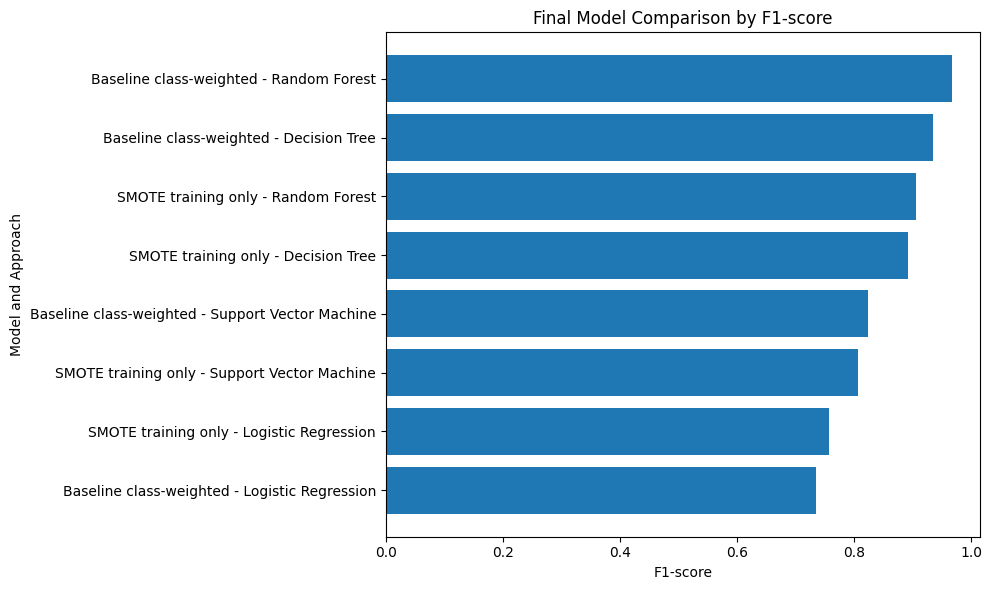

Saved: outputs/figures/final_model_comparison_f1_score.png


In [24]:
# Save final model comparison figure by F1-score

Path("outputs/figures").mkdir(parents=True, exist_ok=True)

plot_df = final_model_comparison.sort_values("f1_score", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["approach"] + " - " + plot_df["model"], plot_df["f1_score"])
plt.title("Final Model Comparison by F1-score")
plt.xlabel("F1-score")
plt.ylabel("Model and Approach")
plt.tight_layout()

plt.savefig(
    "outputs/figures/final_model_comparison_f1_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: outputs/figures/final_model_comparison_f1_score.png")

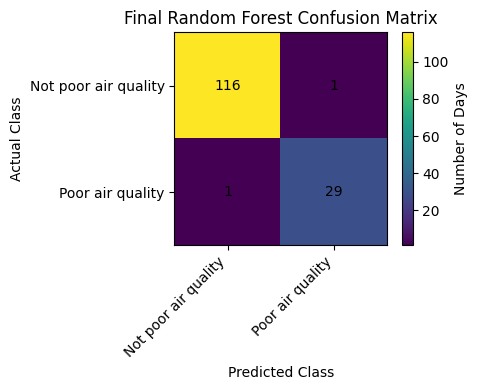

Saved: outputs/figures/final_random_forest_confusion_matrix.png


In [25]:
# Save final recommended model confusion matrix figure

plt.figure(figsize=(5, 4))
plt.imshow(final_cm)
plt.title("Final Random Forest Confusion Matrix")
plt.colorbar(label="Number of Days")

class_labels = ["Not poor air quality", "Poor air quality"]

plt.xticks([0, 1], class_labels, rotation=45, ha="right")
plt.yticks([0, 1], class_labels)

for i in range(final_cm.shape[0]):
    for j in range(final_cm.shape[1]):
        plt.text(j, i, final_cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(
    "outputs/figures/final_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: outputs/figures/final_random_forest_confusion_matrix.png")

In [26]:
# Final Random Forest feature importance

rf_model = baseline_trained_models["Random Forest"]

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.round(4)

,feature,importance
0,daily_max_8hr_ozone,0.3270
2,daily_mean_pm25,0.2693
1,daily_mean_pm10,0.1092
4,tmax,0.0912
8,month,0.0781
5,tmin,0.0440
3,daily_max_1hr_no2,0.0372
7,awnd,0.0292
6,prcp,0.0122
9,is_weekend,0.0026


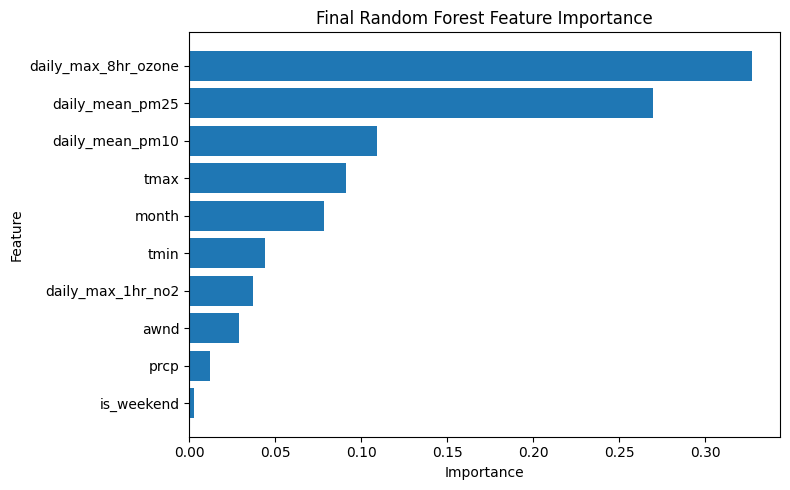

Saved:
outputs/tables/final_random_forest_feature_importance.csv
outputs/figures/final_random_forest_feature_importance.png


In [27]:
# Save final Random Forest feature importance table and figure

feature_importance.to_csv(
    "outputs/tables/final_random_forest_feature_importance.csv",
    index=False
)

plot_importance = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.title("Final Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "outputs/figures/final_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("outputs/tables/final_random_forest_feature_importance.csv")
print("outputs/figures/final_random_forest_feature_importance.png")

In [28]:
# Save final model interpretation text for report drafting

final_model_interpretation = """
The final model comparison showed that the baseline class-weighted Random Forest model performed best overall.
It achieved accuracy = 0.986, precision = 0.967, recall = 0.967, F1-score = 0.967, and ROC-AUC = 0.994
on the holdout test set. The confusion matrix showed 116 true negatives, 29 true positives, one false
positive, and one false negative.

SMOTE was tested as an additional class-imbalance strategy by applying synthetic minority oversampling
only to the training data. The SMOTE-enhanced models did not improve the best-performing model. For Random
Forest, SMOTE preserved recall at 0.967 but reduced precision from 0.967 to 0.853, lowering the F1-score
from 0.967 to 0.906. Therefore, the baseline class-weighted Random Forest model was selected as the final
recommended model.

The final Random Forest feature-importance results should be interpreted as model-based importance rather
than causal evidence. Feature importance identifies which variables contributed most strongly to classification
performance within the trained model.
"""

with open("outputs/tables/final_model_interpretation.txt", "w") as file:
    file.write(final_model_interpretation.strip())

print("Saved: outputs/tables/final_model_interpretation.txt")

Saved: outputs/tables/final_model_interpretation.txt


In [29]:
# Zip and download Notebook 04 final modeling outputs

import shutil
from google.colab import files

zip_file_name = "notebook_04_final_modeling_smote_outputs"

shutil.make_archive(
    zip_file_name,
    "zip",
    "outputs"
)

files.download(f"{zip_file_name}.zip")

print(f"Created and downloaded: {zip_file_name}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created and downloaded: notebook_04_final_modeling_smote_outputs.zip


# 11. Random Forest Hyperparameter Tuning

In [30]:
# Final Check 1: Hyperparameter tuning for Random Forest

from sklearn.model_selection import RandomizedSearchCV

print("Hyperparameter tuning tools imported successfully.")

Hyperparameter tuning tools imported successfully.


In [31]:
# Randomized hyperparameter tuning for Random Forest
# Scoring prioritizes F1-score because the target class is moderately imbalanced.

rf_for_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("Random Forest tuning complete.")
print("Best parameters:")
print(rf_random_search.best_params_)
print("\nBest cross-validated F1-score:")
print(round(rf_random_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest tuning complete.
Best parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10}

Best cross-validated F1-score:
0.935


In [32]:
# Evaluate tuned Random Forest on the holdout test set

tuned_rf_model = rf_random_search.best_estimator_

y_pred_tuned_rf = tuned_rf_model.predict(X_test)
y_score_tuned_rf = tuned_rf_model.predict_proba(X_test)[:, 1]

tuned_rf_results = pd.DataFrame([{
    "model": "Random Forest",
    "approach": "Tuned class-weighted",
    "accuracy": accuracy_score(y_test, y_pred_tuned_rf),
    "precision": precision_score(y_test, y_pred_tuned_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned_rf, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_tuned_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_score_tuned_rf)
}])

print("Tuned Random Forest holdout test performance:")
display(tuned_rf_results.round(3))

print("\nTuned Random Forest confusion matrix:")
print(confusion_matrix(y_test, y_pred_tuned_rf))

print("\nTuned Random Forest classification report:")
print(classification_report(y_test, y_pred_tuned_rf, zero_division=0))

Tuned Random Forest holdout test performance:


,model,approach,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,Tuned class-weighted,0.986,0.967,0.967,0.967,0.993



Tuned Random Forest confusion matrix:
[[116   1]
 [  1  29]]

Tuned Random Forest classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       117
           1       0.97      0.97      0.97        30

    accuracy                           0.99       147
   macro avg       0.98      0.98      0.98       147
weighted avg       0.99      0.99      0.99       147



In [33]:
# Compare Random Forest variants

rf_variant_comparison = pd.concat([
    final_best_row,
    smote_results_df[
        (smote_results_df["model"] == "Random Forest")
    ],
    tuned_rf_results
], ignore_index=True)

rf_variant_comparison = rf_variant_comparison.sort_values(
    ["f1_score", "roc_auc"],
    ascending=False
)

rf_variant_comparison.round(3)

,model,approach,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,Baseline class-weighted,0.986,0.967,0.967,0.967,0.994
2,Random Forest,Tuned class-weighted,0.986,0.967,0.967,0.967,0.993
1,Random Forest,SMOTE training only,0.959,0.853,0.967,0.906,0.992


In [34]:
# Save tuning outputs

tuned_rf_results.to_csv(
    "outputs/tables/final_tuned_random_forest_performance.csv",
    index=False
)

rf_variant_comparison.to_csv(
    "outputs/tables/final_random_forest_variant_comparison.csv",
    index=False
)

# Save best parameters as text
with open("outputs/tables/final_random_forest_tuning_best_params.txt", "w") as file:
    file.write("Best Random Forest parameters:\n")
    file.write(str(rf_random_search.best_params_))
    file.write("\n\nBest cross-validated F1-score:\n")
    file.write(str(round(rf_random_search.best_score_, 4)))

print("Saved:")
print("outputs/tables/final_tuned_random_forest_performance.csv")
print("outputs/tables/final_random_forest_variant_comparison.csv")
print("outputs/tables/final_random_forest_tuning_best_params.txt")

Saved:
outputs/tables/final_tuned_random_forest_performance.csv
outputs/tables/final_random_forest_variant_comparison.csv
outputs/tables/final_random_forest_tuning_best_params.txt


# 12. Chronological Validation

In [35]:
# Final Check 2: Chronological validation
# Data are sorted by date. Earlier 80% is used for training, later 20% for testing.

chrono_df = model_df_imputed.sort_values("date").reset_index(drop=True)

split_index = int(len(chrono_df) * 0.80)

chrono_train = chrono_df.iloc[:split_index].copy()
chrono_test = chrono_df.iloc[split_index:].copy()

X_train_chrono = chrono_train[feature_cols]
y_train_chrono = chrono_train[target_col]

X_test_chrono = chrono_test[feature_cols]
y_test_chrono = chrono_test[target_col]

print("Chronological split created.")
print(f"Training date range: {chrono_train['date'].min().date()} to {chrono_train['date'].max().date()}")
print(f"Test date range: {chrono_test['date'].min().date()} to {chrono_test['date'].max().date()}")

print("\nChronological training set:", X_train_chrono.shape)
print("Chronological test set:", X_test_chrono.shape)

print("\nChronological training target distribution:")
print(y_train_chrono.value_counts().sort_index())

print("\nChronological test target distribution:")
print(y_test_chrono.value_counts().sort_index())

print("\nChronological training target distribution (%):")
print((y_train_chrono.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nChronological test target distribution (%):")
print((y_test_chrono.value_counts(normalize=True).sort_index() * 100).round(2))

Chronological split created.
Training date range: 2024-01-01 to 2025-08-06
Test date range: 2025-08-07 to 2025-12-31

Chronological training set: (584, 10)
Chronological test set: (147, 10)

Chronological training target distribution:
poor_air_quality
0    444
1    140
Name: count, dtype: int64

Chronological test target distribution:
poor_air_quality
0    137
1     10
Name: count, dtype: int64

Chronological training target distribution (%):
poor_air_quality
0    76.03
1    23.97
Name: proportion, dtype: float64

Chronological test target distribution (%):
poor_air_quality
0    93.2
1     6.8
Name: proportion, dtype: float64


In [36]:
# Evaluate baseline class-weighted Random Forest using chronological validation

chrono_rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=8,
    random_state=42
)

chrono_rf_model.fit(X_train_chrono, y_train_chrono)

y_pred_chrono_rf = chrono_rf_model.predict(X_test_chrono)
y_score_chrono_rf = chrono_rf_model.predict_proba(X_test_chrono)[:, 1]

chrono_rf_results = pd.DataFrame([{
    "model": "Random Forest",
    "approach": "Chronological validation baseline class-weighted",
    "training_period": f"{chrono_train['date'].min().date()} to {chrono_train['date'].max().date()}",
    "test_period": f"{chrono_test['date'].min().date()} to {chrono_test['date'].max().date()}",
    "accuracy": accuracy_score(y_test_chrono, y_pred_chrono_rf),
    "precision": precision_score(y_test_chrono, y_pred_chrono_rf, zero_division=0),
    "recall": recall_score(y_test_chrono, y_pred_chrono_rf, zero_division=0),
    "f1_score": f1_score(y_test_chrono, y_pred_chrono_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test_chrono, y_score_chrono_rf)
}])

chrono_rf_results.round(3)

,model,approach,training_period,test_period,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,Chronological validation baseline class-weighted,2024-01-01 to 2025-08-06,2025-08-07 to 2025-12-31,0.993,1.0,0.9,0.947,0.996


In [37]:
# Chronological validation confusion matrix and classification report

chrono_cm = confusion_matrix(y_test_chrono, y_pred_chrono_rf)

print("Chronological validation confusion matrix:")
print(chrono_cm)

print("\nChronological validation classification report:")
print(classification_report(y_test_chrono, y_pred_chrono_rf, zero_division=0))

Chronological validation confusion matrix:
[[137   0]
 [  1   9]]

Chronological validation classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       137
           1       1.00      0.90      0.95        10

    accuracy                           0.99       147
   macro avg       1.00      0.95      0.97       147
weighted avg       0.99      0.99      0.99       147



In [38]:
# Save chronological validation outputs

chrono_rf_results.to_csv(
    "outputs/tables/final_chronological_random_forest_validation.csv",
    index=False
)

# Save chronological confusion matrix as table
chrono_cm_df = pd.DataFrame(
    chrono_cm,
    index=["Actual not poor", "Actual poor"],
    columns=["Predicted not poor", "Predicted poor"]
)

chrono_cm_df.to_csv(
    "outputs/tables/final_chronological_random_forest_confusion_matrix.csv"
)

print("Saved:")
print("outputs/tables/final_chronological_random_forest_validation.csv")
print("outputs/tables/final_chronological_random_forest_confusion_matrix.csv")

Saved:
outputs/tables/final_chronological_random_forest_validation.csv
outputs/tables/final_chronological_random_forest_confusion_matrix.csv


In [39]:
# Zip and download updated Notebook 04 outputs

import shutil
from google.colab import files

zip_file_name = "notebook_04_final_modeling_smote_tuning_chrono_outputs"

shutil.make_archive(
    zip_file_name,
    "zip",
    "outputs"
)

files.download(f"{zip_file_name}.zip")

print(f"Created and downloaded: {zip_file_name}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created and downloaded: notebook_04_final_modeling_smote_tuning_chrono_outputs.zip
